# ConvNeXt-Tiny v5 — Train only 학습 + 확장 테스트셋 평가

## v4 → v5 변경 사항

| 항목 | v4 | v5 | 근거 |
|------|----|----|------|
| 학습 데이터 | train 80% | **train 80%** (동일) | Stratified split 유지 |
| Val 사용 여부 | val 20% → early stopping + best model 선택 | **val 제거** | val 데이터를 테스트셋에 포함시키기 위해 |
| Best model 기준 | val_acc 최고점 | **train_acc 최고점** | val 없으므로 train 기준 선택 |
| Early stopping | val_acc 기준 patience=10 | **train_acc 기준 patience=10** | 개선 없으면 조기 종료 |
| 테스트셋 | test_final (158장) | **val 20% + test_final** | 더 많은 데이터로 신뢰도 높은 평가 |


## 0. 공통 설정

In [16]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageOps
from collections import defaultdict, Counter

# ── 재현성
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── 경로
DATA_DIR  = './preprocess'
TEST_DIR  = './test1_orientation_backup'
SAVE_DIR  = './checkpoints_v5'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 하이퍼파라미터
IMG_SIZE    = 224
BATCH_SIZE  = 32
WARMUP_EP   = 5
FINETUNE_EP = 40
LR_HEAD     = 1e-3
LR_FULL     = 5e-5
LLRD_DECAY  = 0.8
TRAIN_RATIO = 0.8      # ⭐ v5: val 없이 train 80% / 나머지는 테스트용으로 보관
PATIENCE    = 10       # ⭐ v5: train_acc 기준 early stopping
NUM_WORKERS = 0

CLASSES     = ['mug', 'straight', 'taper_smooth', 'taper_step']
NUM_CLASSES = len(CLASSES)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

print('설정 완료')


디바이스: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
설정 완료


## 1. Transform 정의 (v4와 동일)

In [2]:
NORMALIZE = transforms.Normalize(mean=MEAN, std=STD)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.35, p=0.4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    NORMALIZE,
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    NORMALIZE,
])

print('Transform 정의 완료')


Transform 정의 완료


## 2. 데이터 분할

> **v5 핵심**: val을 완전히 제거하고 학습은 train만 진행
> - `train_samples`: preprocess/ 80% → 학습에 사용
> - `held_out_samples`: preprocess/ 20% → 테스트셋에 포함 (학습에는 절대 미사용)
> - `test_final_samples`: test_final/ 전체 → 테스트셋에 포함


In [17]:
# ── 테스트셋 test1_orientation
def list_samples(root):
    samples = []
    for cls in CLASSES:
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for name in sorted(os.listdir(cls_dir)):
            if os.path.splitext(name)[1].lower() in ('.jpg', '.jpeg', '.png'):
                samples.append((os.path.join(cls_dir, name), CLASSES.index(cls)))
    return samples
test_final_samples = list_samples(TEST_DIR)

In [3]:
def exif_safe_loader(path):
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img)
        return img.convert('RGB')


class ConnectorDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(exif_safe_loader(path)), label


def list_samples(root):
    samples = []
    for cls in CLASSES:
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for name in sorted(os.listdir(cls_dir)):
            if os.path.splitext(name)[1].lower() in ('.jpg', '.jpeg', '.png'):
                samples.append((os.path.join(cls_dir, name), CLASSES.index(cls)))
    return samples


# ── Stratified Split (동일 seed → v4와 동일한 분할 유지)
all_samples = list_samples(DATA_DIR)
by_class    = defaultdict(list)
for s in all_samples:
    by_class[s[1]].append(s)

rng = random.Random(SEED)
train_samples, held_out_samples = [], []
for items in by_class.values():
    items = items[:]
    rng.shuffle(items)
    n_held = max(1, int(len(items) * (1 - TRAIN_RATIO)))
    held_out_samples.extend(items[:n_held])   # ⭐ 이전 val = 이제 테스트용
    train_samples.extend(items[n_held:])

# ── 테스트셋 = held_out + test_final
test_final_samples = list_samples(TEST_DIR)
combined_test_samples = held_out_samples + test_final_samples

# ── 학습용 DataLoader (val 없음)
train_loader = DataLoader(ConnectorDataset(train_samples, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train    : {len(train_samples)}장')
print(f'Held-out : {len(held_out_samples)}장  (preprocess 20% — 테스트셋에 포함)')
print(f'Test-final: {len(test_final_samples)}장  (test_final/ 폴더)')
print(f'테스트셋 합계: {len(combined_test_samples)}장')
print()
tr_cnt = Counter([s[1] for s in train_samples])
print('클래스별 train 수:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:14s}: {tr_cnt[i]}장')


Train    : 516장
Held-out : 126장  (preprocess 20% — 테스트셋에 포함)
Test-final: 158장  (test_final/ 폴더)
테스트셋 합계: 284장

클래스별 train 수:
  mug           : 139장
  straight      : 141장
  taper_smooth  : 119장
  taper_step    : 117장


## 3. 모델 정의 (ConvNeXt-Tiny)

In [4]:
torch.manual_seed(SEED)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'ConvNeXt-Tiny | 총 파라미터: {total/1e6:.1f}M')


ConvNeXt-Tiny | 총 파라미터: 27.8M


## 4. LLRD 파라미터 그룹 (v4와 동일)

In [5]:
def build_llrd_params(model, base_lr, decay=LLRD_DECAY):
    param_groups = []
    stages = list(model.features.children())
    n = len(stages)
    for i, stage in enumerate(stages):
        lr_i = base_lr * (decay ** (n - 1 - i))
        param_groups.append({'params': list(stage.parameters()), 'lr': lr_i})
    param_groups.append({'params': list(model.classifier.parameters()), 'lr': base_lr})
    return param_groups

print('LLRD 준비 완료')


LLRD 준비 완료


## 5. 학습 함수

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


print('학습 함수 정의 완료')


학습 함수 정의 완료


## 6. Stage 1: Warmup (Head만 학습)

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for name, p in model.named_parameters():
    p.requires_grad = ('classifier' in name)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scaler    = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EP, eta_min=1e-6)

hist = {'train_loss':[], 'train_acc':[]}
best_acc, best_state, no_improve = 0.0, None, 0

print('=== Stage 1: Warmup (Head only) ===')
print(f"{'Epoch':>5}  {'Tr Loss':>8}  {'Tr Acc':>7}")
print('-' * 28)

for epoch in range(1, WARMUP_EP + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    scheduler.step()
    hist['train_loss'].append(tr_loss)
    hist['train_acc'].append(tr_acc)

    # ⭐ v5: train_acc 기준으로 best model 선택
    if tr_acc > best_acc:
        best_acc   = tr_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%")

print(f'\nWarmup 완료 | Best Train Acc: {best_acc*100:.2f}%')


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_42336\17477867.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


=== Stage 1: Warmup (Head only) ===
Epoch   Tr Loss   Tr Acc
----------------------------


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_42336\2305286247.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    1    1.1310   59.88%
    2    0.7574   83.33%
    3    0.6360   90.31%
    4    0.6093   90.70%
    5    0.6009   90.89%

Warmup 완료 | Best Train Acc: 90.89%


## 7. Stage 2: Finetune (LLRD + train_acc 기준 Early Stopping)

> **v5 핵심**: val 없이 train_acc로만 early stopping
> - train_acc가 PATIENCE(10) epoch 연속 개선 없으면 중단
> - Best model = train_acc 최고점 기준 저장


In [8]:
for p in model.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(
    build_llrd_params(model, base_lr=LR_FULL * 10, decay=LLRD_DECAY),
    weight_decay=1e-4
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EP, eta_min=1e-7)
scaler     = GradScaler()
no_improve = 0
best_epoch = 0

print('=== Stage 2: Finetune (LLRD, train_acc early stopping) ===')
print(f"{'Epoch':>5}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Best':>7}  {'No Imp':>6}")
print('-' * 45)

for epoch in range(1, FINETUNE_EP + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    scheduler.step()
    hist['train_loss'].append(tr_loss)
    hist['train_acc'].append(tr_acc)

    # ⭐ v5: train_acc 기준 best model + early stopping
    if tr_acc > best_acc:
        best_acc   = tr_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch = epoch + WARMUP_EP
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 5 == 0 or no_improve == 0:
        print(f"{epoch+WARMUP_EP:>5}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%  {best_acc*100:>6.2f}%  {no_improve:>6}")

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping @ epoch {epoch + WARMUP_EP}  (train_acc 개선 없음 {PATIENCE}회)')
        break

save_path = os.path.join(SAVE_DIR, 'best_convnext_v5.pth')
torch.save(best_state, save_path)
print(f'\n최고 Train Acc: {best_acc*100:.2f}%  (epoch {best_epoch})  →  {save_path}')


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_42336\2584038449.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_42336\2305286247.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


=== Stage 2: Finetune (LLRD, train_acc early stopping) ===
Epoch   Tr Loss   Tr Acc     Best  No Imp
---------------------------------------------
    6    0.5338   92.44%   92.44%       0
    7    0.4625   95.74%   95.74%       0
    8    0.4278   97.09%   97.09%       0
    9    0.4087   98.64%   98.64%       0
   10    0.4350   96.71%   98.64%       1
   11    0.3833   98.84%   98.84%       0
   14    0.3675   99.61%   99.61%       0
   15    0.3593   99.61%   99.61%       1
   20    0.3611   99.61%   99.61%       6
   21    0.3582   99.81%   99.81%       0
   25    0.3699   99.03%   99.81%       4
   30    0.3580   99.81%   99.81%       9

Early stopping @ epoch 31  (train_acc 개선 없음 10회)

최고 Train Acc: 99.81%  (epoch 21)  →  ./checkpoints_v5\best_convnext_v5.pth


## 8. 학습 곡선

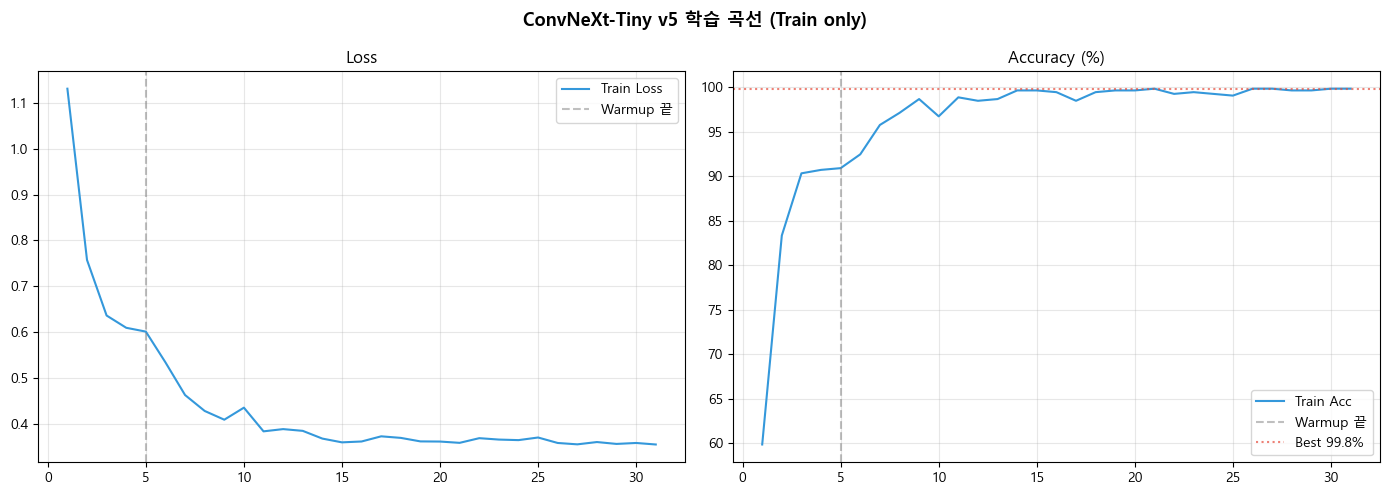

In [9]:
epochs = range(1, len(hist['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ConvNeXt-Tiny v5 학습 곡선 (Train only)', fontsize=13, fontweight='bold')

axes[0].plot(epochs, hist['train_loss'], label='Train Loss', color='#3498DB')
axes[0].axvline(WARMUP_EP, color='gray', linestyle='--', alpha=0.5, label='Warmup 끝')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [v*100 for v in hist['train_acc']], label='Train Acc', color='#3498DB')
axes[1].axvline(WARMUP_EP, color='gray', linestyle='--', alpha=0.5, label='Warmup 끝')
axes[1].axhline(best_acc*100, color='#E74C3C', linestyle=':', alpha=0.7, label=f'Best {best_acc*100:.1f}%')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'train_curve_v5.png'), dpi=150)
plt.show()


## 9. Test 평가 — held_out + test_final 합산

> **v5 테스트셋**: preprocess/ val 20% (held_out) + test_final/ 전체


In [18]:
model.load_state_dict(best_state)
model.eval()

test_img_paths = [s[0] for s in test_final_samples]
test_labels    = [s[1] for s in test_final_samples]

print(f'테스트셋 구성:')
#print(f'  test_final                : {len(test_final_samples)}장')
#print(f'  합계                       : {len(combined_test_samples)}장')
print()
cnt = Counter(test_labels)
for i, cls in enumerate(CLASSES):
    print(f'  {cls:14s}: {cnt[i]}장')


@torch.no_grad()
def predict_single(img_path, model, transform):
    img   = exif_safe_loader(img_path)
    inp   = transform(img).unsqueeze(0).to(DEVICE)
    out   = model(inp)
    probs = torch.softmax(out, dim=1).squeeze().cpu().numpy()
    return int(probs.argmax()), probs


all_preds, all_probs = [], []
for path in tqdm(test_img_paths, desc='추론'):
    pred, probs = predict_single(path, model, eval_tf)
    all_preds.append(pred)
    all_probs.append(probs)

acc = sum(p == t for p, t in zip(all_preds, test_labels)) / len(test_labels)
print(f'\n전체 Test Accuracy (합산): {acc*100:.2f}%')
print('\n=== Classification Report ===')
print(classification_report(test_labels, all_preds, target_names=CLASSES))

print('\n' + '='*50)
print('  클래스별 상세 결과')
print('='*50)
for cls_idx, cls_name in enumerate(CLASSES):
    cls_indices = [i for i, l in enumerate(test_labels) if l == cls_idx]
    correct = sum(all_preds[i] == cls_idx for i in cls_indices)
    total   = len(cls_indices)
    recall  = correct / total if total > 0 else 0
    status  = 'PASS ✅' if recall >= 0.7 else 'FAIL ❌'
    errors  = {}
    for i in cls_indices:
        if all_preds[i] != cls_idx:
            errors[CLASSES[all_preds[i]]] = errors.get(CLASSES[all_preds[i]], 0) + 1
    err_str = ', '.join(f'{k}:{v}' for k, v in errors.items()) if errors else '없음'
    print(f'  {status}  {cls_name:14s}  Recall {recall*100:5.1f}%  ({correct}/{total})')
    print(f'         오분류 → {err_str}')
print('='*50)

# ── held_out / test_final 별도 정확도
#held_n = len(held_out_samples)
#held_preds  = all_preds[:held_n];  held_labels  = test_labels[:held_n]
#final_preds = all_preds[held_n:];  final_labels = test_labels[held_n:]
#held_acc  = sum(p==t for p,t in zip(held_preds, held_labels))  / max(held_n, 1)
#final_acc = sum(p==t for p,t in zip(final_preds, final_labels)) / max(len(final_labels), 1)
#print(f'\n  held_out 정확도  : {held_acc*100:.2f}%  ({held_n}장)')
print(f'  test_final 정확도: {final_acc*100:.2f}%  ({len(final_labels)}장)')


테스트셋 구성:

  mug           : 22장
  straight      : 39장
  taper_smooth  : 32장
  taper_step    : 33장


추론:   0%|          | 0/126 [00:00<?, ?it/s]

추론: 100%|██████████| 126/126 [00:19<00:00,  6.41it/s]


전체 Test Accuracy (합산): 90.48%

=== Classification Report ===
              precision    recall  f1-score   support

         mug       0.94      0.77      0.85        22
    straight       0.95      0.90      0.92        39
taper_smooth       0.78      1.00      0.88        32
  taper_step       1.00      0.91      0.95        33

    accuracy                           0.90       126
   macro avg       0.92      0.89      0.90       126
weighted avg       0.92      0.90      0.91       126


  클래스별 상세 결과
  PASS ✅  mug             Recall  77.3%  (17/22)
         오분류 → taper_smooth:3, straight:2
  PASS ✅  straight        Recall  89.7%  (35/39)
         오분류 → taper_smooth:4
  PASS ✅  taper_smooth    Recall 100.0%  (32/32)
         오분류 → 없음
  PASS ✅  taper_step      Recall  90.9%  (30/33)
         오분류 → mug:1, taper_smooth:2
  test_final 정확도: 90.51%  (158장)


## 10. Confusion Matrix

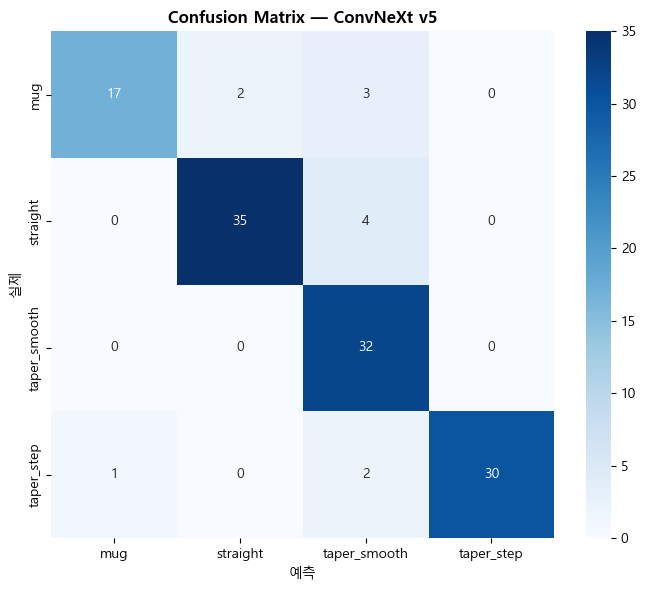

In [19]:
cm = confusion_matrix(test_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix — ConvNeXt v5', fontsize=12, fontweight='bold')
ax.set_ylabel('실제'); ax.set_xlabel('예측')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cm_v5_only_test_orien.png'), dpi=150)
plt.show()


## 11. GradCAM — 팀원 방식 (v4와 동일)

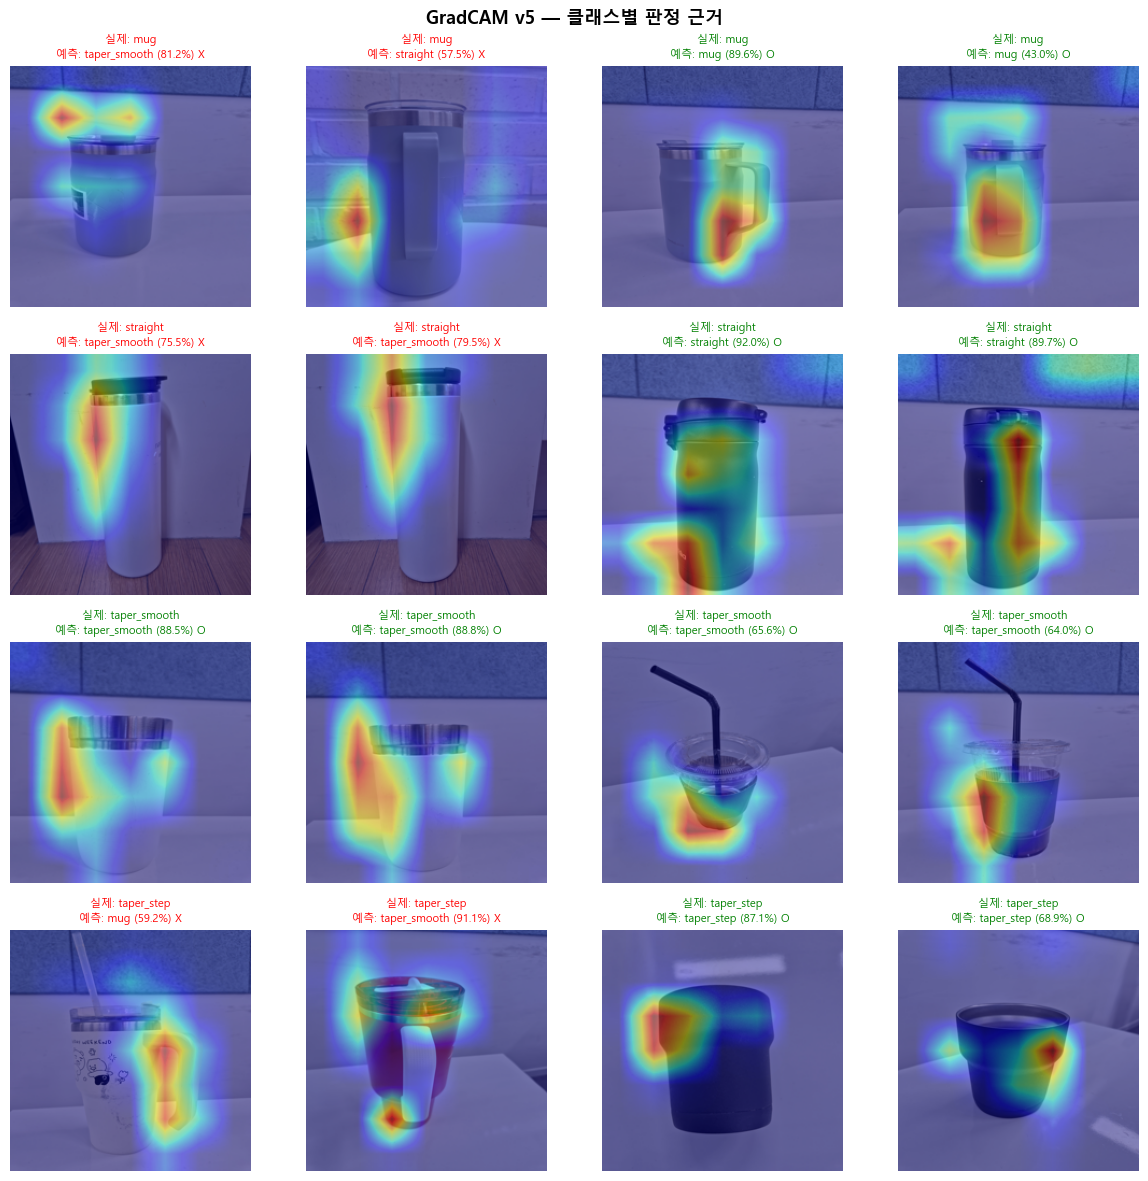

GradCAM 저장 완료


In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output     = self.model(input_tensor)
        pred_idx   = int(output.argmax(dim=1).item())
        target_idx = pred_idx if class_idx is None else class_idx
        output[0, target_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam[0, 0].cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, pred_idx, output.softmax(dim=1)[0].detach().cpu().numpy()


def overlay_cam(rgb_uint8, cam):
    cam_resized = cv2.resize(cam, (rgb_uint8.shape[1], rgb_uint8.shape[0]))
    heatmap     = (plt.get_cmap('jet')(cam_resized)[:, :, :3] * 255).astype(np.uint8)
    return (0.45 * heatmap + 0.55 * rgb_uint8).astype(np.uint8)


target_layer = model.features[-1][-1]
cam_engine   = GradCAM(model, target_layer)

PER_CLASS = 4
fig, axes = plt.subplots(NUM_CLASSES, PER_CLASS, figsize=(3*PER_CLASS, 3*NUM_CLASSES))
fig.suptitle('GradCAM v5 — 클래스별 판정 근거', fontsize=13, fontweight='bold')

by_cls = {c: [] for c in CLASSES}
for i, (path, label) in enumerate(zip(test_img_paths, test_labels)):
    by_cls[CLASSES[label]].append((path, all_preds[i]))

model.eval()
for row, cls_name in enumerate(CLASSES):
    cls_idx = CLASSES.index(cls_name)
    items   = by_cls[cls_name]
    wrong   = [(p, pr) for p, pr in items if pr != cls_idx]
    right   = [(p, pr) for p, pr in items if pr == cls_idx]
    show    = (wrong[:2] + right)[:PER_CLASS]

    for col, (path, pred_idx) in enumerate(show):
        img_pil = exif_safe_loader(path)
        img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        inp     = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
        cam, _, probs = cam_engine(inp)
        overlay = overlay_cam(img_np, cam)
        mark  = 'O' if pred_idx == cls_idx else 'X'
        color = 'green' if pred_idx == cls_idx else 'red'
        axes[row][col].imshow(overlay)
        axes[row][col].set_title(
            f'실제: {cls_name}\n예측: {CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%) {mark}',
            fontsize=8, color=color)
        axes[row][col].axis('off')
    for col in range(len(show), PER_CLASS):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradcam_v5_only_test_orien.png'), dpi=120, bbox_inches='tight')
plt.show()
print('GradCAM 저장 완료')


## 12. 최종 결과 요약

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(test_labels, all_preds, average='macro')
per_f1   = f1_score(test_labels, all_preds, average=None)

print('┌──────────────────────────────────────────────────┐')
print('│          ConvNeXt-Tiny v5 최종 결과              │')
print('├──────────────────────────────────────────────────┤')
print(f'│  Test Accuracy (합산)  : {acc*100:>6.2f}%                │')
print(f'│    ├ held_out          : {held_acc*100:>6.2f}%  ({held_n}장)        │')
print(f'│    └ test_final        : {final_acc*100:>6.2f}%  ({len(final_labels)}장)       │')
print(f'│  Macro F1              : {macro_f1:>6.4f}                 │')
print('├──────────────────────────────────────────────────┤')
for i, cls in enumerate(CLASSES):
    print(f'│  {cls:14s} F1 : {per_f1[i]:>6.4f}                 │')
print('├──────────────────────────────────────────────────┤')
print('│  v5 변경사항                                      │')
print('│  ✅ Val 제거 → train_acc 기준 best model          │')
print('│  ✅ Early stopping: train_acc patience=10         │')
print('│  ✅ 테스트셋 확장: held_out + test_final 합산     │')
print('│  ✅ LLRD + RandomErasing + RandomPerspective 유지 │')
print('└──────────────────────────────────────────────────┘')
